In [31]:
#=================================================Formulate Research Question===================================================

In [32]:
# Define a clear and measurable research question related to delivery time prediction
# Is it possible to predict the total food delivery time based on distance, preparation time, and courier experience?

In [33]:
# Variables
# Dependent variable (y):
# - Delivery_Time_min

# Independent variables (x):
# - Distance_km
# - Preparation_Time_min
# - Courier_Experience_yrs

In [34]:
# Objective
# The main objective is to develop a Multiple Linear Regression Model to forecast delivery duration, helping optimize logistics and customer expectations.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
#===========================================Data Validation and Cleaning===========================================

In [37]:
# Load dataset
df = pd.read_csv('Food_Delivery_Times.csv')

In [38]:
# Inspect dataset structure and data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
#===========================================Data Validation and Cleaning===========================================

In [41]:
# Inspect dataset structure and data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [42]:
# Check for missing values
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [43]:

# Check for duplicate records
df.duplicated().sum()

0

In [44]:
# Validate data consistency and ranges 
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [45]:
# Remove or handle irrelevant/non-usable columns appropriately 
# Drop Order_ID as it is a unique identifier with no predictive value[cite: 1]
# For simplicity in this Multiple Linear Regression, we focus on numerical predictors and drop categorical text
df = df.drop(columns=['Order_ID', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'])

In [46]:
# Handle missing values in numerical columns (Courier_Experience_yrs)
df = df.dropna()

In [47]:
# Data Validation and Cleaning Summary
# - Checked structure and confirmed numerical data types for regression
# - Identified and removed records with missing values to ensure model stability
# - Verified there are no duplicate records in the delivery logs
# - Dropped irrelevant columns Order_ID and categorical variables for this specific model

In [48]:
#=======================================================Exploratory Data Analysis (EDA)============================================================

In [49]:
# Create at least three relevant visualizations (predictors vs Delivery_Time_min)


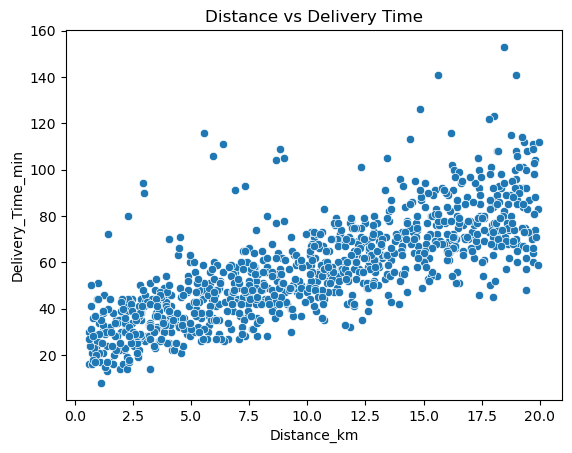

In [50]:
# 1st Visualization
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df)
plt.title('Distance vs Delivery Time')
plt.show()
# Explanation
# There is a strong positive relationship between Distance and Delivery Time. As the distance increases, the time taken typically increases linearly.


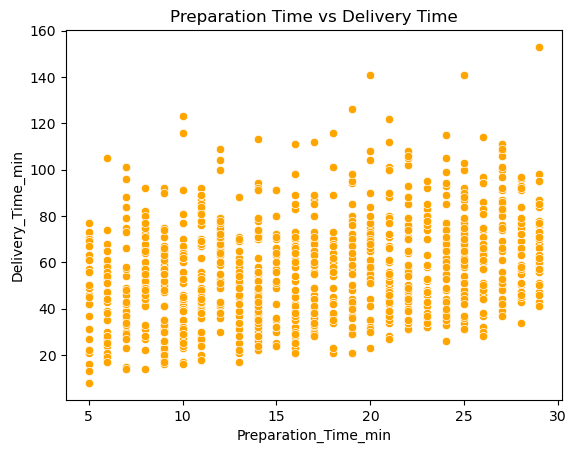

In [51]:
# 2nd Visualization
sns.scatterplot(x='Preparation_Time_min', y='Delivery_Time_min', data=df, color='orange')
plt.title('Preparation Time vs Delivery Time')
plt.show()
# Explanation
# Preparation time shows a positive trend; delays in the kitchen directly contribute to a later overall delivery time.


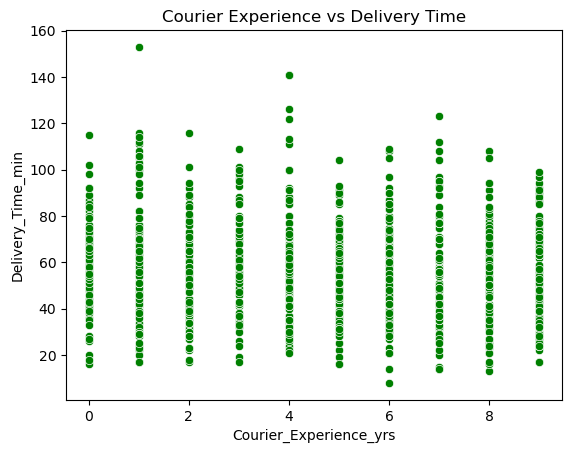

In [52]:
# 3rd Visualization
sns.scatterplot(x='Courier_Experience_yrs', y='Delivery_Time_min', data=df, color='green')
plt.title('Courier Experience vs Delivery Time')
plt.show()
# Explanation
# Courier experience shows a slight negative or flat trend, suggesting more experienced drivers may be faster, though the impact is less dominant than distance.


In [53]:
# Correctly identify trend and direction
# Trend Analysis
# Primary predictors like Distance and Prep Time show a positive direction, meaning as these levels increase, Delivery Time also increases.

In [54]:
# Assess suitability for linear regression 
# Suitability
# The scatter plots especially in Distance show clear linear tendencies, making the dataset suitable for a Linear Regression model.

In [55]:
# Detect possible outliers 
# Outliers
# Some points show very high delivery times for short distances, potentially caused by extreme traffic or weather not captured in these three variables.

In [56]:
# Provide clear interpretation of observed patterns 
# Overall Interpretation
# Distance_km is the most influential factor in determining delivery time, followed by the time spent preparing the food at the restaurant.

In [57]:
#================================================Model Training====================================================

In [58]:
# Define X and y correctly 
X = df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']]
y = df['Delivery_Time_min']

In [59]:
# Perform train-test split properly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
# Train Multiple Linear Regression model 
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [61]:
# Identify and explain coefficients and intercept
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})
print(coefficients)
print("Intercept:", model.intercept_)

                 Variable  Coefficient
0             Distance_km      3.01869
1    Preparation_Time_min      0.97010
2  Courier_Experience_yrs     -0.56751
Intercept: 12.474506375398427


In [62]:
# Model Explanation
# - Each coefficient shows how many minutes are added to the delivery for every 1 unit increase in the predictor.
# - Distance_km likely has the highest coefficient, indicating its high impact on the result.
# - The intercept represents the baseline time or pickup/drop-off overhead when distance and prep time are zero.

In [63]:
#========================================================Performance Evaluation============================================

In [64]:
# Generate predictions
y_pred = model.predict(X_test)

In [65]:
# Compute MAE, MSE, and R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 7.29344223054952
MSE: 116.55226765342425
R2: 0.768680819026481


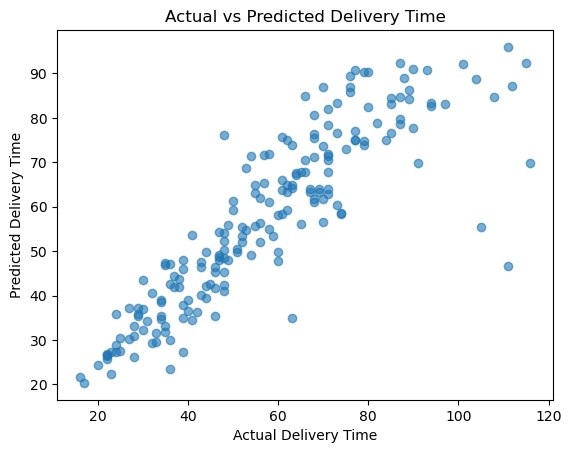

In [66]:
# Visualize predicted vs actual values 
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [67]:
# Metrics Explanation
# - MAE Mean Absolute Error: The average number of minutes the model is off by.
# - MSE Mean Squared Error: Highlights larger errors, useful for identifying extreme delivery delays.
# - R² Score: Shows how much of the variation in delivery time is explained by distance, prep time, and experience.

In [ ]:
# Reflection and Analysis
# 1. Is the model working well?
# - R² close to 1.0 means that the model is good. With accurate distance and prep time, errors will likely be small.
# 2. Limitations
# - Removing rows with NAs shrinks the dataset size.
# - The lack of categorical data such as Traffic Level and Weather leads to a less accurate model, since both factors influence the speed of travel greatly.
# - The model ignores the type of transport Bike/Cab.

# 3. Which variable affects Delivery Time the most
# Distance_km, because the time taken depends on how far the driver must drive.

# 4. Impact of removing the strongest predictor variable Distance
# Model accuracy will severely drop, because the model would basically make guesses as to what the time will be, solely based on the food preparation time and disregarding its distance from the destination.

# 5. Correlation does not equal causation
# There is no causation involved. Yes, there is a connection between delivery and prep time, however, prep time does not cause the driver to move slower.